# 03 — Análisis científico (SQL + Python)

**Pregunta:** ¿Cómo evoluciona $N/Z$ frente al modo dominante ($\beta^-$ vs $\beta^+$/EC), cuál es la correlación entre $Q_\beta$ y la vida media, y cómo se sitúa eso respecto al valle (BE/A y residual LDM)?

Las consultas viven en `sql/queries.sql`. Aquí se ejecutan contra MySQL (host `mysql` dentro de Docker, o `127.0.0.1` desde el host) y se interpretan con Pandas/Matplotlib.

Filtros de análisis: estados base (`level_index = 0`), sin resonancias en las correlaciones $Q$–$t_{1/2}$, y $Q>0$ solo cuando el canal está abierto.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
if not (ROOT / "sql" / "queries.sql").exists():
    ROOT = Path(".").resolve()
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

host = os.getenv("MYSQL_HOST", "127.0.0.1")
port = os.getenv("MYSQL_PORT", "3306")
user = os.getenv("MYSQL_USER", "nudat")
password = os.getenv("MYSQL_PASSWORD", "nudat")
database = os.getenv("MYSQL_DATABASE", "nudat")
url = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
engine = create_engine(url, pool_pre_ping=True)

with engine.connect() as conn:
    print(conn.execute(text("SELECT DATABASE(), USER()")).fetchone())
print("MYSQL_HOST =", host)


('nudat', 'nudat@172.19.0.1')
MYSQL_HOST = 127.0.0.1


## 1. Consultas básicas y agrupadas

Conteo de estados base y $N/Z$ medio por modo dominante.


In [2]:
q_modes = text('''
SELECT
  ns.dominant_mode,
  COUNT(*) AS n_nuclides,
  ROUND(AVG(n.N / NULLIF(n.Z, 0)), 3) AS mean_N_over_Z,
  ROUND(STDDEV_SAMP(n.N / NULLIF(n.Z, 0)), 3) AS sd_N_over_Z
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
GROUP BY ns.dominant_mode
ORDER BY n_nuclides DESC
''')
modes = pd.read_sql(q_modes, engine)
modes


,dominant_mode,n_nuclides,mean_N_over_Z,sd_N_over_Z
0,B-,1377,1.609,0.185
1,EC_BP,1091,1.206,0.186
2,ALPHA,469,1.400,0.134
3,STABLE,253,1.306,0.174
4,OTHER,181,1.405,0.786


### Interpretación

Los emisores $\beta^-$ tienen, en promedio, **$N/Z$ más alto** que los de EC/$\beta^+$: el lado rico en neutrones decae convirtiendo $n\to p$, y el lado deficiente en neutrones hace lo contrario. Los estables quedan entre ambos, sobre el valle.


In [3]:
q_frontier = text('''
SELECT
  FLOOR(n.Z / 10) * 10 AS Z_bin,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'B-' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_beta_minus,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'EC_BP' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_ec_bp,
  SUM(ns.dominant_mode = 'B-') AS n_beta_minus,
  SUM(ns.dominant_mode = 'EC_BP') AS n_ec_bp
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode IN ('B-', 'EC_BP')
GROUP BY FLOOR(n.Z / 10) * 10
ORDER BY Z_bin
''')
frontier = pd.read_sql(q_frontier, engine)
frontier


,Z_bin,mean_nz_beta_minus,mean_nz_ec_bp,n_beta_minus,n_ec_bp
0,0,1.886,0.755,49.0,12.0
1,10,1.675,0.844,146.0,45.0
2,20,1.592,0.963,169.0,81.0
3,30,1.580,1.064,179.0,110.0
4,40,1.582,1.107,226.0,126.0
5,50,1.605,1.210,181.0,166.0
6,60,1.575,1.251,144.0,189.0
7,70,1.581,1.321,121.0,189.0
8,80,1.620,1.383,113.0,102.0
9,90,1.594,1.490,49.0,56.0


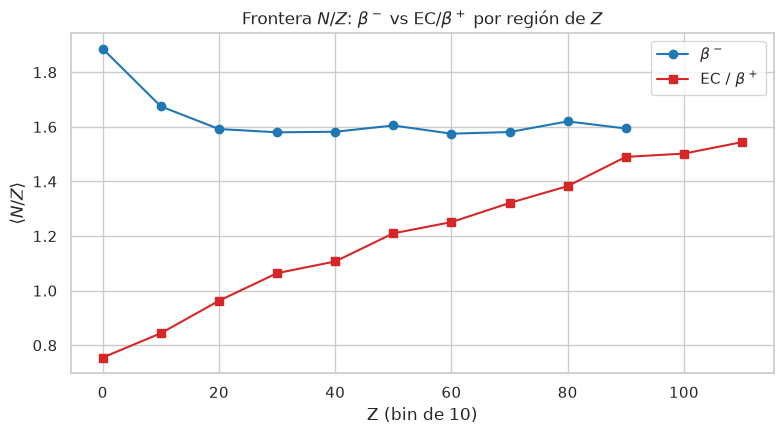

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(frontier["Z_bin"], frontier["mean_nz_beta_minus"], "o-", label=r"$\beta^-$", color="#1f77b4")
ax.plot(frontier["Z_bin"], frontier["mean_nz_ec_bp"], "s-", label=r"EC / $\beta^+$", color="#d62728")
ax.set_xlabel("Z (bin de 10)")
ax.set_ylabel(r"$\langle N/Z \rangle$")
ax.set_title(r"Frontera $N/Z$: $\beta^-$ vs EC/$\beta^+$ por región de $Z$")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "03_frontera_NZ.png", dpi=130)
plt.show()


### Interpretación

En cada franja de $Z$, el $N/Z$ medio de $\beta^-$ está **por encima** del de EC/$\beta^+$. Esa separación es la frontera del valle: a un $Z$ dado, más neutrones → $\beta^-$; menos neutrones → captura/$\beta^+$.


## 2. Chart y valle (JOIN estado + estructura)


3371 estados base con estructura


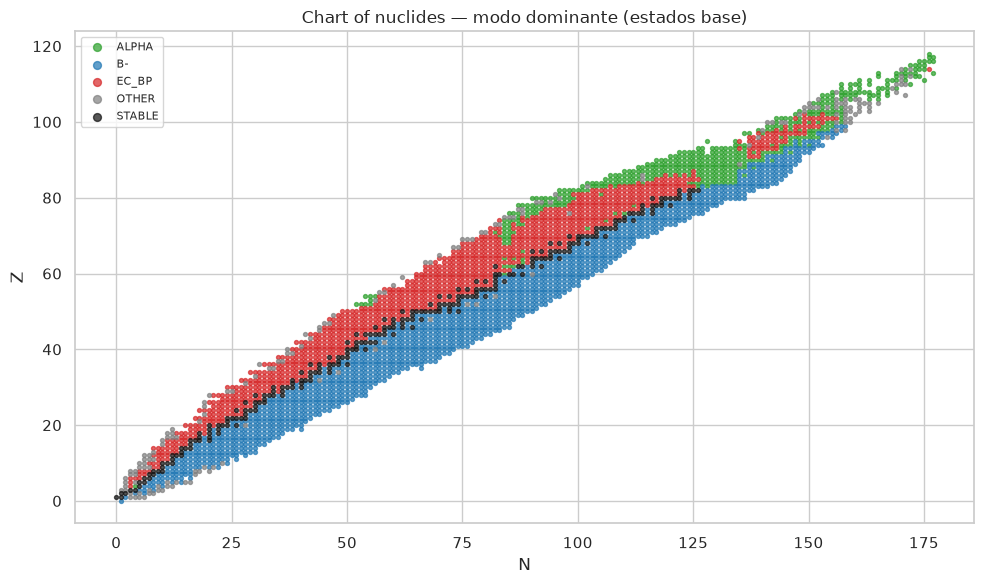

In [5]:
q_chart = text('''
SELECT
  n.Z, n.N, n.A, n.name,
  n.N / NULLIF(n.Z, 0) AS N_over_Z,
  ns.dominant_mode,
  ns.is_stable,
  ns.half_life_s,
  s.be_per_a_keV,
  s.be_ldm_residual_keV
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_structure s ON s.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
''')
chart = pd.read_sql(q_chart, engine)
print(len(chart), "estados base con estructura")

palette = {
    "B-": "#1f77b4", "EC_BP": "#d62728", "ALPHA": "#2ca02c",
    "STABLE": "#111111", "IT": "#9467bd", "OTHER": "#7f7f7f", "UNKNOWN": "#c7c7c7",
}
fig, ax = plt.subplots(figsize=(10, 6))
for mode, sub in chart.groupby("dominant_mode"):
    ax.scatter(sub["N"], sub["Z"], s=8, alpha=0.7, label=mode, c=palette.get(mode, "#aaa"))
ax.set_xlabel("N"); ax.set_ylabel("Z")
ax.set_title("Chart of nuclides — modo dominante (estados base)")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "03_chart_modos.png", dpi=130)
plt.show()


,dominant_mode,n,mean_BE_A,mean_LDM_residual
0,STABLE,253,8247.4,-116.6
1,EC_BP,1091,8123.8,-5.0
2,B-,1377,8075.1,-48.4
3,ALPHA,469,7621.7,-2.4
4,OTHER,181,6917.8,-399.5


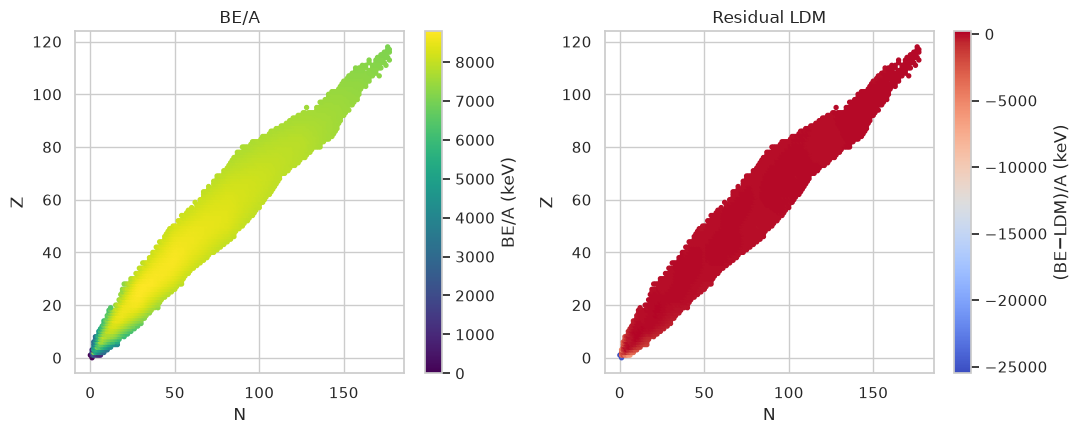

In [6]:
q_valley = text('''
SELECT
  ns.dominant_mode,
  COUNT(*) AS n,
  ROUND(AVG(s.be_per_a_keV), 1) AS mean_BE_A,
  ROUND(AVG(s.be_ldm_residual_keV), 1) AS mean_LDM_residual
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_structure s ON s.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
GROUP BY ns.dominant_mode
ORDER BY mean_BE_A DESC
''')
valley = pd.read_sql(q_valley, engine)
display(valley)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc = axes[0].scatter(chart["N"], chart["Z"], c=chart["be_per_a_keV"], s=8, cmap="viridis")
plt.colorbar(sc, ax=axes[0], label="BE/A (keV)")
axes[0].set_title("BE/A"); axes[0].set_xlabel("N"); axes[0].set_ylabel("Z")
sc2 = axes[1].scatter(chart["N"], chart["Z"], c=chart["be_ldm_residual_keV"], s=8, cmap="coolwarm")
plt.colorbar(sc2, ax=axes[1], label="(BE−LDM)/A (keV)")
axes[1].set_title("Residual LDM"); axes[1].set_xlabel("N"); axes[1].set_ylabel("Z")
plt.tight_layout()
plt.savefig(FIG / "03_valle.png", dpi=130)
plt.show()


### Interpretación

BE/A es máximo cerca del valle (región del hierro y alrededores) y cae hacia driplines y núcleos muy pesados. Los **estables** concentran BE/A alto: son el fondo del valle. El residual LDM resalta desviaciones de capas respecto a la gota líquida, no solo la tendencia suave.


## 3. Correlación $Q$ vs vida media

Subconjunto: modo dominante correspondiente, $Q>0$, $t_{1/2}>0$, sin resonancias. Pearson se calcula en Pandas sobre el resultado del JOIN.


β− puntos: 1196 Pearson Q vs log t1/2: -0.74
EC puntos: 1071 Pearson Q vs log t1/2: -0.771


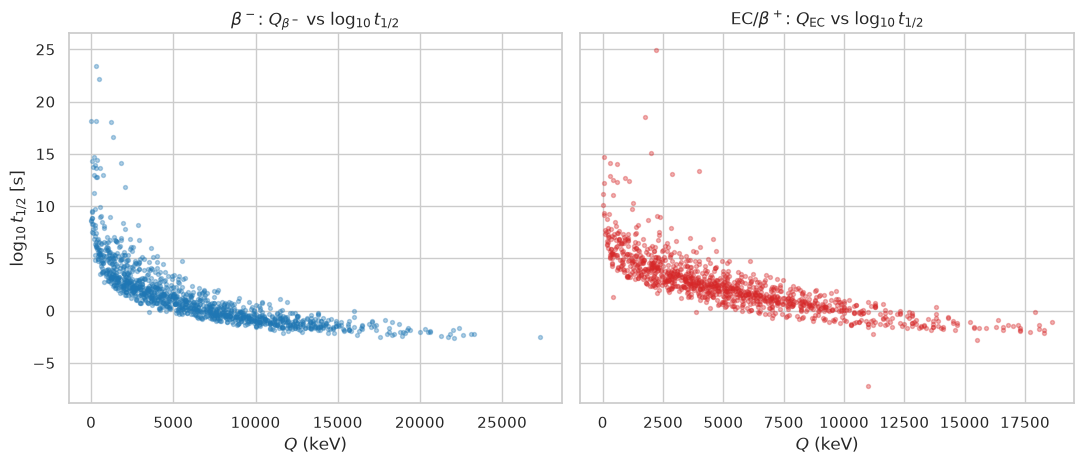

In [7]:
q_beta = text('''
SELECT
  n.name, n.Z, n.A,
  q.q_beta_minus_keV AS Q_keV,
  ns.half_life_s,
  LOG10(ns.half_life_s) AS log10_t12
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_qvalue q ON q.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode = 'B-'
  AND ns.is_resonance = 0
  AND ns.half_life_s > 0
  AND q.q_beta_minus_keV > 0
''')
q_ec = text('''
SELECT
  n.name, n.Z, n.A,
  q.q_ec_keV AS Q_keV,
  ns.half_life_s,
  LOG10(ns.half_life_s) AS log10_t12
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_qvalue q ON q.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode = 'EC_BP'
  AND ns.is_resonance = 0
  AND ns.half_life_s > 0
  AND q.q_ec_keV > 0
''')
beta = pd.read_sql(q_beta, engine)
ec = pd.read_sql(q_ec, engine)
print("β− puntos:", len(beta), "Pearson Q vs log t1/2:", round(beta[["Q_keV","log10_t12"]].corr().iloc[0,1], 3))
print("EC puntos:", len(ec), "Pearson Q vs log t1/2:", round(ec[["Q_keV","log10_t12"]].corr().iloc[0,1], 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
axes[0].scatter(beta["Q_keV"], beta["log10_t12"], s=8, alpha=0.35, c="#1f77b4")
axes[0].set_title(r"$\beta^-$: $Q_{\beta^-}$ vs $\log_{10} t_{1/2}$")
axes[0].set_xlabel(r"$Q$ (keV)"); axes[0].set_ylabel(r"$\log_{10} t_{1/2}$ [s]")
axes[1].scatter(ec["Q_keV"], ec["log10_t12"], s=8, alpha=0.35, c="#d62728")
axes[1].set_title(r"EC/$\beta^+$: $Q_{\mathrm{EC}}$ vs $\log_{10} t_{1/2}$")
axes[1].set_xlabel(r"$Q$ (keV)")
plt.tight_layout()
plt.savefig(FIG / "03_Q_vs_halflife.png", dpi=130)
plt.show()


,Q_bin_keV,n,mean_log10_t12
0,0.0,229,5.711
1,2000.0,232,2.662
2,4000.0,175,1.273
3,6000.0,153,0.240
4,8000.0,129,-0.407
5,10000.0,111,-0.851
6,12000.0,81,-1.229
7,14000.0,39,-1.456
8,16000.0,18,-1.425
9,18000.0,14,-1.930


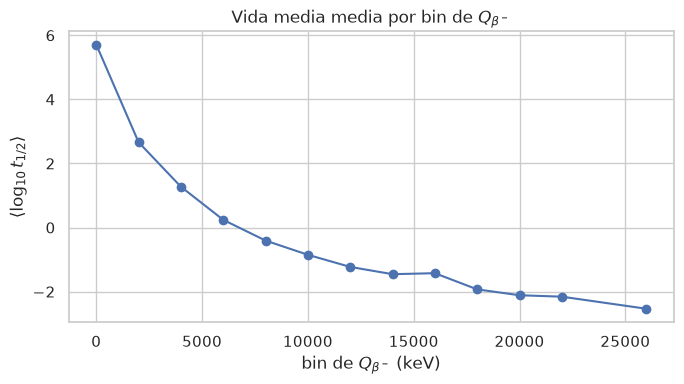

In [8]:
q_bins = text('''
SELECT
  FLOOR(q.q_beta_minus_keV / 2000) * 2000 AS Q_bin_keV,
  COUNT(*) AS n,
  ROUND(AVG(LOG10(ns.half_life_s)), 3) AS mean_log10_t12
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_qvalue q ON q.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode = 'B-'
  AND ns.is_resonance = 0
  AND ns.half_life_s > 0
  AND q.q_beta_minus_keV > 0
GROUP BY FLOOR(q.q_beta_minus_keV / 2000) * 2000
ORDER BY Q_bin_keV
''')
bins = pd.read_sql(q_bins, engine)
display(bins)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bins["Q_bin_keV"], bins["mean_log10_t12"], "o-")
ax.set_xlabel(r"bin de $Q_{\beta^-}$ (keV)")
ax.set_ylabel(r"$\langle \log_{10} t_{1/2}\rangle$")
ax.set_title(r"Vida media media por bin de $Q_{\beta^-}$")
plt.tight_layout()
plt.savefig(FIG / "03_Q_bins.png", dpi=120)
plt.show()


### Interpretación

La correlación de Pearson entre $Q$ y $\log_{10} t_{1/2}$ es **negativa**: a mayor energía disponible, vidas medias más cortas, como predice el espacio de fase de la teoría de Fermi. La dispersión es grande porque también importan la prohibición de espín-paridad y la estructura nuclear; $Q$ no es el único factor.

El mismo patrón aparece, en promedio, al agrupar por bins de $Q_{\beta^-}$.


## 4. Subconsulta: núcleo de máximo BE/A en cada $Z$

Ejemplo de consulta anidada: el isótopo más ligado por nucleón de cada cadena isotópica (núcleo del valle para ese $Z$).


In [9]:
q_max = text('''
SELECT n.Z, n.A, n.name, s.be_per_a_keV, ns.dominant_mode, ns.is_stable
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
JOIN nuclide_structure s ON s.nuclide_id = n.nuclide_id
WHERE ns.level_index = 0
  AND s.be_per_a_keV = (
    SELECT MAX(s2.be_per_a_keV)
    FROM nuclide n2
    JOIN nuclide_structure s2 ON s2.nuclide_id = n2.nuclide_id
    WHERE n2.Z = n.Z
  )
ORDER BY n.Z
''')
core = pd.read_sql(q_max, engine)
print("filas (máximo BE/A por Z):", len(core))
print("fracción estable entre esos máximos:", round(core["is_stable"].mean(), 3))
core.head(12)


filas (máximo BE/A por Z): 333
fracción estable entre esos máximos: 0.228


,Z,A,name,be_per_a_keV,dominant_mode,is_stable
0,0,1,Neutron,0.0,B-,0
1,1,3,3H,2820.0,B-,0
2,2,4,4He,7070.0,STABLE,1
3,3,7,7Li,5600.0,STABLE,1
4,4,8,8Be,7060.0,ALPHA,0
5,5,11,11B,6920.0,STABLE,1
6,6,12,12C,7680.0,STABLE,1
7,7,15,15N,7690.0,STABLE,1
8,8,16,16O,7970.0,STABLE,1
9,9,19,19F,7770.0,STABLE,1


### Interpretación

El isótopo de mayor BE/A en cada $Z$ cae cerca de la línea de estabilidad: una fracción importante es `STABLE` o de vida muy larga. Eso conecta el valle energético (BE/A) con la observación de modos: lejos de ese máximo dominan $\beta^-$ o EC/$\beta^+$.


## 5. Respuesta a la pregunta

1. **$N/Z$ y modo.** $\beta^-$ ocupa $N/Z$ sistemáticamente mayor que EC/$\beta^+$; los estables quedan en medio. En el chart, azul (rico en $N$) y rojo (pobre en $N$) flanquean el valle.
2. **$Q$ y vida media.** Para $\beta^-$ y para EC, $\log t_{1/2}$ disminuye al crecer $Q>0$ (correlación negativa), con mucha dispersión estructural.
3. **Valle.** BE/A mapea el valle; los estables y los máximos de BE/A por $Z$ se alinean con esa franja. El residual LDM muestra estructura más allá de la gota líquida.

Consultas de referencia: `sql/queries.sql`. Figuras en `figures/03_*.png`.
